# All Alloy Categories — Combined Evaluation

**92 alloys, 496 datapoints, −196 to 1205°C** — SSS (Hastelloy, Inconel 600/625), γ′ (Waspaloy, IN-738, Astroloy), SC/DS (PWA\*1480, René N5, CMSX-8/10).

Four ablation levels: **ML-only** → **ML + deterministic physics** → **Full system (+ KG + agents)** → **LLM-only** baseline.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                      'font.size': 10, 'figure.facecolor': 'white'})

R = Path('../results/all')
ml   = pd.read_csv(R / 'ml_only.csv')
det  = pd.read_csv(R / 'ml_deterministic.csv')
full = pd.read_csv(R / 'full_system.csv')
llm  = pd.read_csv(R / 'llm_only.csv')

METHODS = {'ML': ml, 'ML+Phys': det, 'Full': full, 'LLM': llm}
COLORS  = {'ML': '#4C72B0', 'ML+Phys': '#55A868', 'Full': '#C44E52', 'LLM': '#8172B2'}
PROPS   = [('pred_ys','actual_ys','YS (MPa)'), ('pred_uts','actual_uts','UTS (MPa)'),
           ('pred_el','actual_el','EL (%)'),    ('pred_em','actual_em','EM (GPa)')]

def metrics(df, pc, ac):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)<2: return dict(n=len(v), mape=np.nan, rmse=np.nan, r2=np.nan, bias=np.nan)
    e = v[pc]-v[ac]; pe = e/v[ac]
    return dict(n=len(v), mape=pe.abs().mean()*100, rmse=np.sqrt((e**2).mean()),
                r2=r2_score(v[ac], v[pc]), bias=pe.mean()*100)

def pct_within(df, pc, ac, tol):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)==0: return np.nan
    return (((v[pc]-v[ac])/v[ac]).abs()*100 <= tol).mean()*100

## Table 1 — Aggregate Accuracy

In [2]:
rows = []
for mn, df in METHODS.items():
    for pc, ac, lbl in PROPS:
        m = metrics(df, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '±10%': pct_within(df,pc,ac,10), '±20%': pct_within(df,pc,ac,20)})

tbl = pd.DataFrame(rows)
for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = tbl[tbl['Property']==prop][['Method','n','mape','rmse','r2','bias','±10%','±20%']].set_index('Method')
    sub.columns = ['n','MAPE %','RMSE','R²','Bias %','±10%','±20%']
    print(f"\n{prop}")
    display(sub.style.format({'MAPE %':'{:.1f}','RMSE':'{:.1f}','R²':'{:.3f}',
                              'Bias %':'{:+.1f}','±10%':'{:.0f}%','±20%':'{:.0f}%','n':'{:.0f}'})
            .highlight_min(subset=['MAPE %','RMSE'], props='font-weight:bold;color:green')
            .highlight_max(subset=['R²','±10%','±20%'], props='font-weight:bold;color:green'))


YS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,310,76.0,145.3,0.789,+67.1,35%,55%
ML+Phys,310,76.0,145.3,0.789,+67.1,35%,55%
Full,290,35.0,122.6,0.844,+23.3,42%,62%
LLM,310,98.0,332.1,-0.101,+84.5,17%,30%



UTS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,314,35.8,154.4,0.818,+29.0,40%,62%
ML+Phys,314,37.8,155.2,0.816,+30.3,39%,63%
Full,292,23.0,136.8,0.853,+9.8,39%,68%
LLM,314,65.5,305.8,0.285,+58.7,21%,36%



EL (%)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,309,81.3,26.5,0.240,+51.3,17%,34%
ML+Phys,309,81.4,26.5,0.239,+51.2,16%,34%
Full,289,89.1,26.8,0.262,+54.4,19%,37%
LLM,309,97.4,33.5,-0.216,+35.8,9%,19%



EM (GPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,304,7.4,20.2,0.446,-3.6,79%,87%
ML+Phys,304,5.7,13.8,0.740,-1.8,85%,95%
Full,277,5.9,13.9,0.743,-1.5,88%,95%
LLM,304,60141.0,153783.6,-32155136.757,+60140.2,26%,37%


## Table 2 — Accuracy by Temperature Regime

MAPE (%) for YS and UTS split into three regimes: RT (< 100°C), mid-temperature (100–700°C), and high-temperature (> 700°C).

In [3]:
def temp_regime(t):
    if t < 100: return 'RT (< 100\u00b0C)'
    elif t <= 700: return 'Mid (100\u2013700\u00b0C)'
    else: return 'High (> 700\u00b0C)'

REGIMES = ['RT (< 100\u00b0C)', 'Mid (100\u2013700\u00b0C)', 'High (> 700\u00b0C)']

rows = []
for mn, df in METHODS.items():
    df = df.copy()
    df['regime'] = df['temperature'].apply(temp_regime)
    for regime in REGIMES:
        sub = df[df['regime'] == regime]
        for pc, ac, lbl in [('pred_ys','actual_ys','YS'), ('pred_uts','actual_uts','UTS')]:
            m = metrics(sub, pc, ac)
            rows.append({'Regime': regime, 'Property': lbl, 'Method': mn,
                         'n': m['n'], 'MAPE': m['mape']})

temp_tbl = pd.DataFrame(rows)
pivot = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='MAPE')
pivot = pivot[['ML', 'ML+Phys', 'Full', 'LLM']]

n_ref = temp_tbl[temp_tbl['Method']=='ML'][['Regime','Property','n']].set_index(['Regime','Property'])
pivot = n_ref.join(pivot)
pivot.index = pivot.index.set_levels([REGIMES, ['YS', 'UTS']])

display(pivot.style.format({'n': '{:.0f}', 'ML': '{:.1f}', 'ML+Phys': '{:.1f}',
                            'Full': '{:.1f}', 'LLM': '{:.1f}'}, na_rep='\u2014')
        .highlight_min(subset=['ML', 'ML+Phys', 'Full', 'LLM'], axis=1,
                       props='font-weight:bold;color:green'))

## Fig. 1 — Cumulative Accuracy Curves

What tolerance band is needed to capture 80% of predictions?

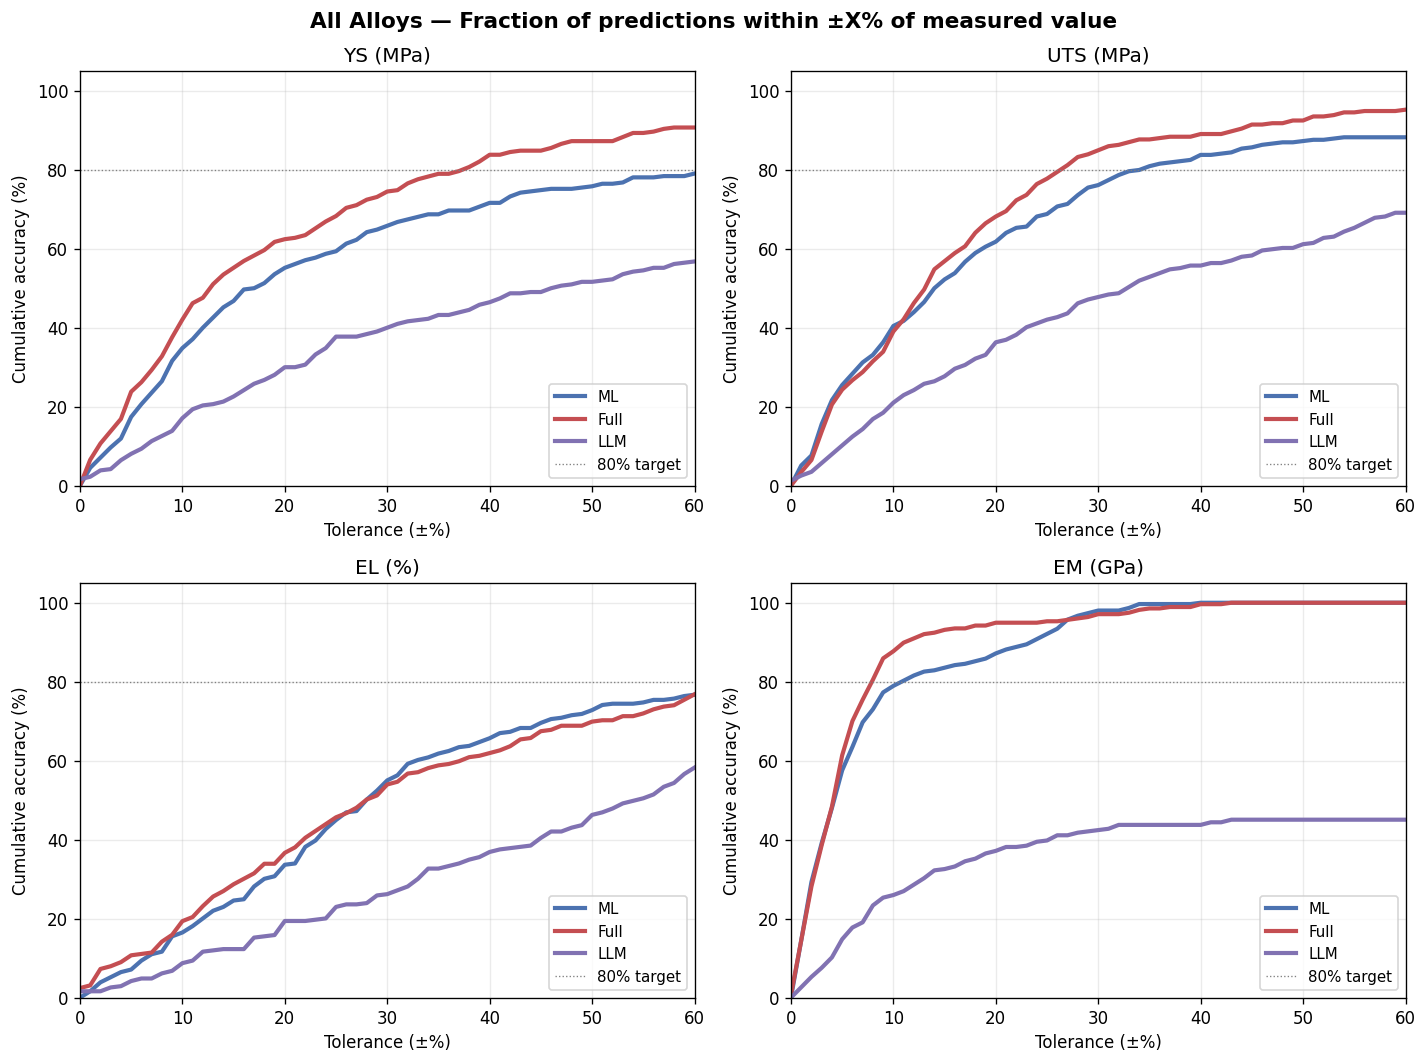

In [4]:
PLOT_METHODS = {'ML': ml, 'Full': full, 'LLM': llm}
PLOT_COLORS  = {'ML': '#4C72B0', 'Full': '#C44E52', 'LLM': '#8172B2'}

tol = np.arange(0, 61, 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    for mn, df in PLOT_METHODS.items():
        acc = [pct_within(df, pc, ac, t) for t in tol]
        ax.plot(tol, acc, label=mn, color=PLOT_COLORS[mn], lw=2.5)
    ax.axhline(80, color='gray', ls=':', lw=0.8, label='80% target')
    ax.set(xlabel='Tolerance (\u00b1%)', ylabel='Cumulative accuracy (%)',
           title=lbl, xlim=(0, 60), ylim=(0, 105))
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('All Alloys \u2014 Fraction of predictions within \u00b1X% of measured value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 2 — Predicted vs Measured (Full System)

Parity plots for all four properties. Green band = ±10% tolerance; points within band shown in blue, outliers as red crosses.

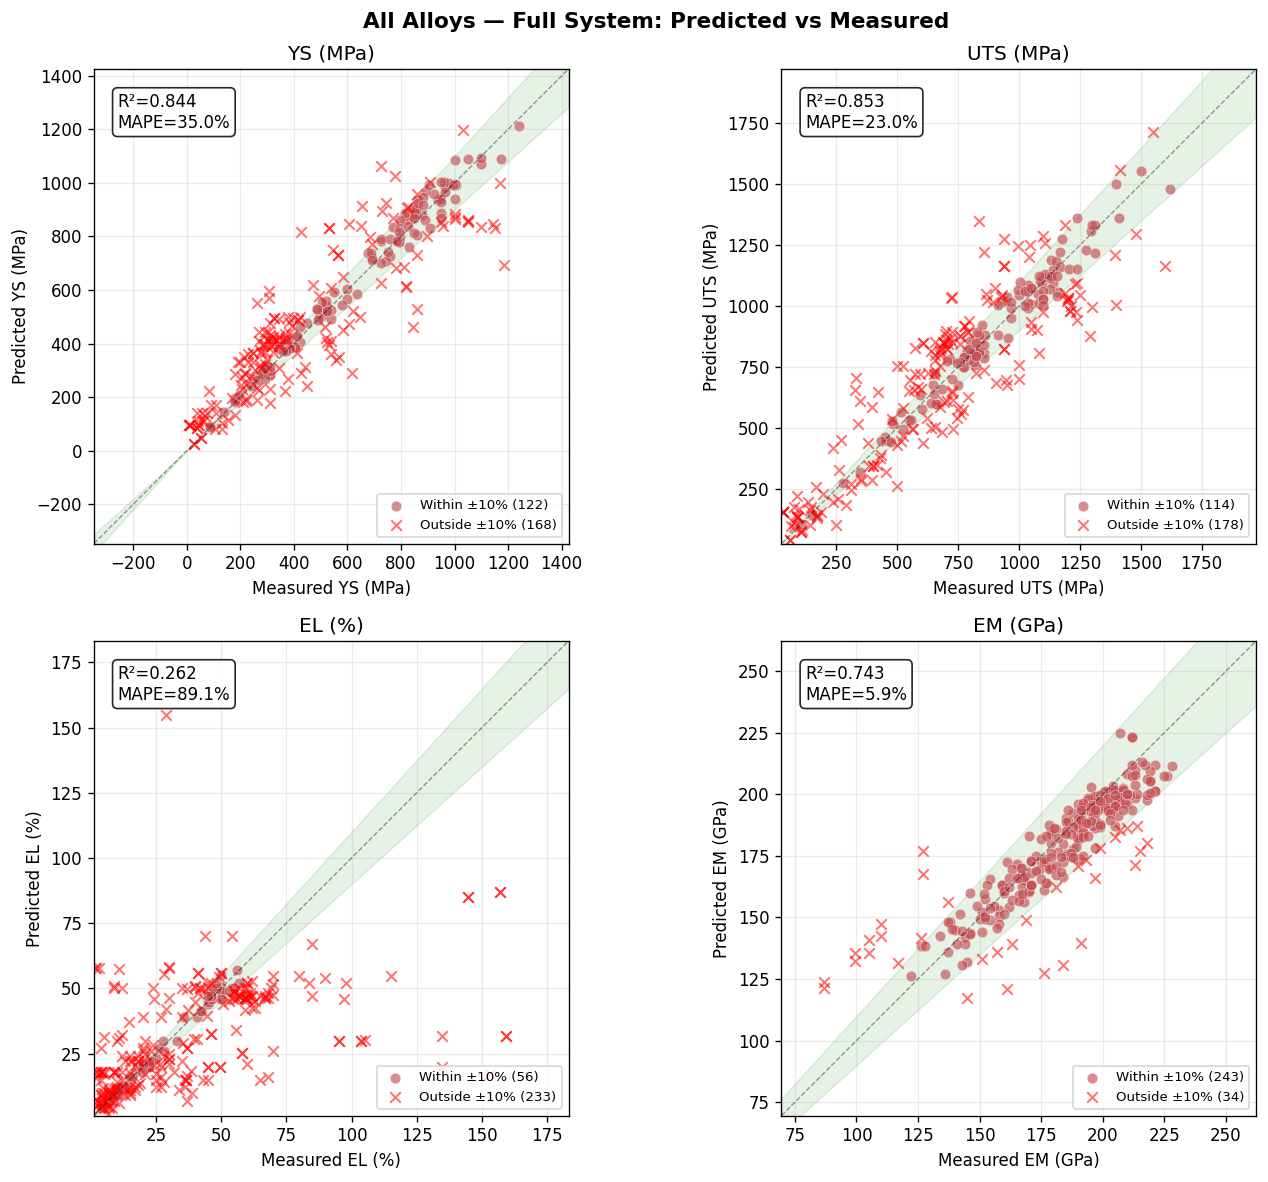

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    v = full[[pc, ac]].dropna()
    v = v[v[ac] != 0].copy()
    m = metrics(full, pc, ac)
    if len(v) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes,
                ha='center', fontsize=11)
        ax.set(title=lbl)
        continue
    pe = ((v[pc] - v[ac]) / v[ac]).abs() * 100
    w = pe <= 10

    lo = min(v[ac].min(), v[pc].min()) * 0.8
    hi = max(v[ac].max(), v[pc].max()) * 1.15
    d = np.linspace(lo, hi, 100)
    ax.fill_between(d, d * 0.9, d * 1.1, alpha=0.10, color='green')
    ax.plot(d, d, 'k--', lw=0.8, alpha=0.4)

    ax.scatter(v.loc[w, ac], v.loc[w, pc], s=40, alpha=0.65,
               color=COLORS['Full'], edgecolors='white', lw=0.3,
               label=f'Within ±10% ({w.sum()})')
    ax.scatter(v.loc[~w, ac], v.loc[~w, pc], s=40, alpha=0.55,
               color='red', marker='x', lw=1.2,
               label=f'Outside ±10% ({(~w).sum()})')

    ax.text(0.05, 0.95, f"R²={m['r2']:.3f}\nMAPE={m['mape']:.1f}%",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set(xlabel=f'Measured {lbl}', ylabel=f'Predicted {lbl}',
           title=lbl, xlim=(lo, hi), ylim=(lo, hi), aspect='equal')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('All Alloys — Full System: Predicted vs Measured', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 3 — Case Studies: Temperature Sweeps

One representative alloy per category — Waspaloy (γ′), Inconel N06230 (SSS), PWA\*1480 (SC) — showing YS and UTS predictions against published datasheet values.

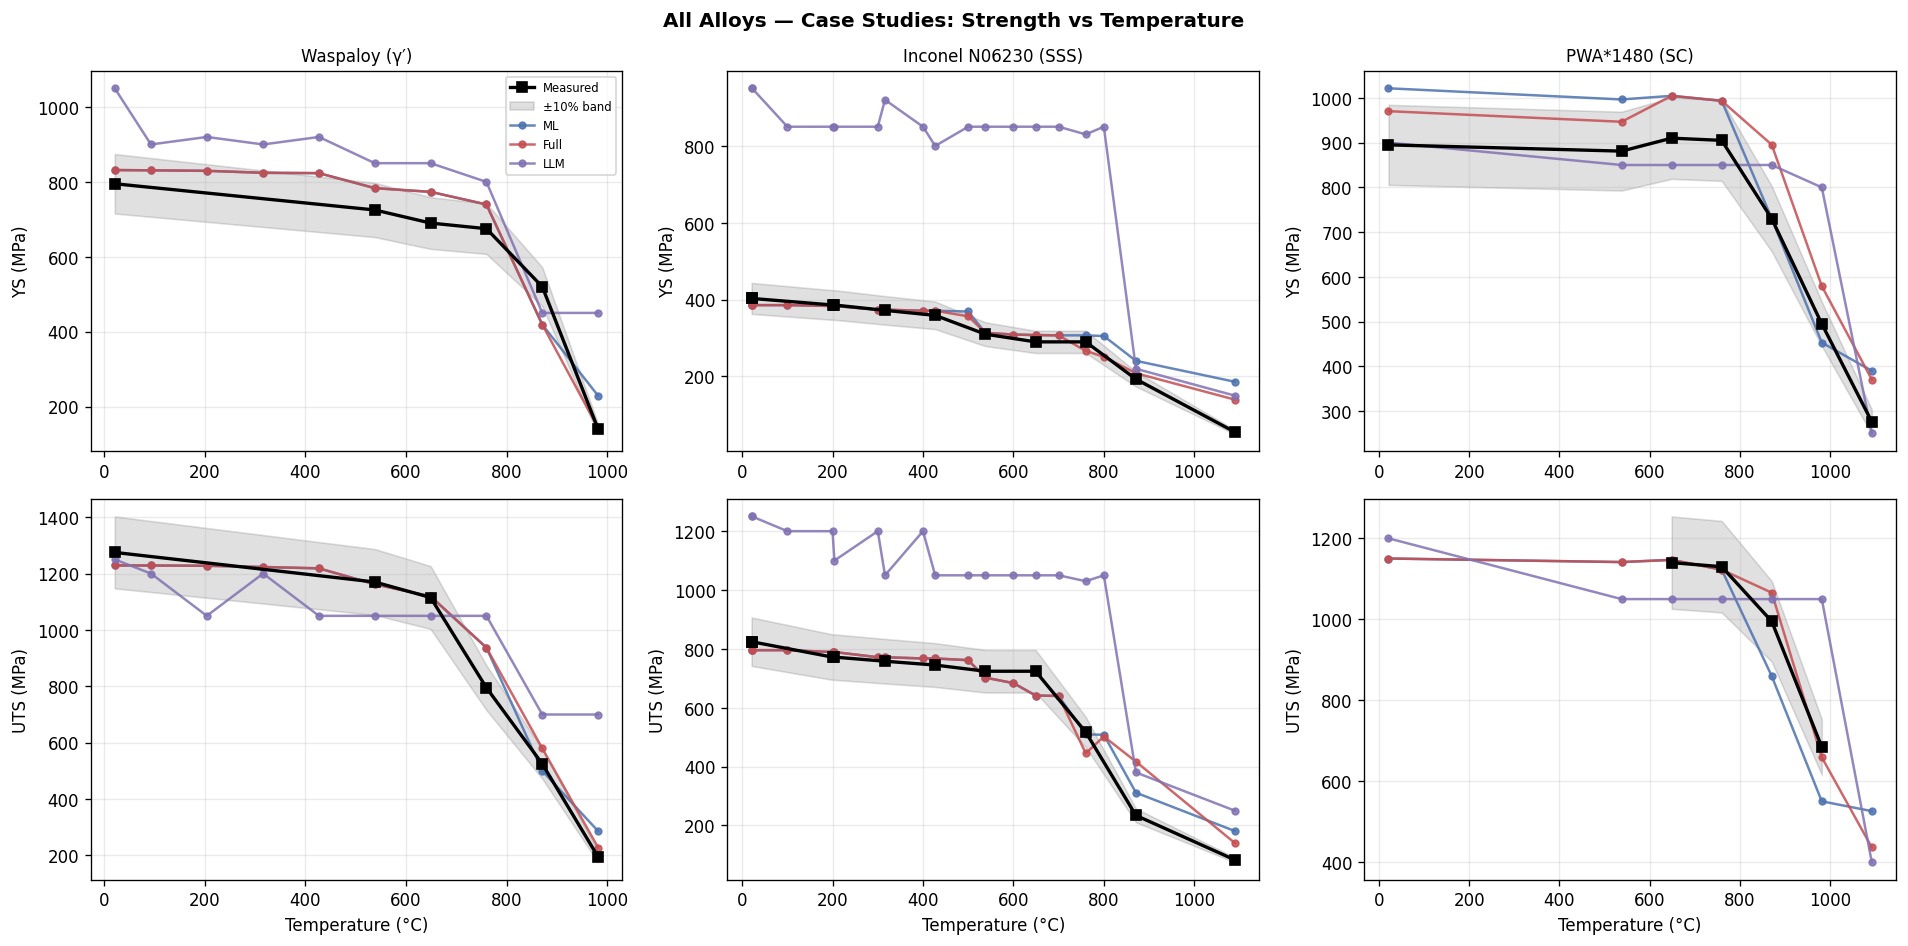

In [6]:
cases = ['WASPALOY*',
         'Special Metals INCONEL\u00ae Alloy N06230 Ni-Cr-W-Mo Alloy',
         'PWA*1480(SC)']
short_names = ['Waspaloy (\u03b3\u2032)', 'Inconel N06230 (SSS)', 'PWA*1480 (SC)']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('All Alloys \u2014 Case Studies: Strength vs Temperature', fontsize=12, fontweight='bold')

for col, (alloy, sname) in enumerate(zip(cases, short_names)):
    for row, (pc, ac, ylabel) in enumerate([('pred_ys','actual_ys','YS (MPa)'),
                                             ('pred_uts','actual_uts','UTS (MPa)')]):
        ax = axes[row, col]
        ref = ml[ml['alloy']==alloy].sort_values('temperature')
        actual = ref[['temperature',ac]].dropna()
        if not actual.empty:
            ax.plot(actual['temperature'], actual[ac], 'ks-', ms=6, lw=2,
                    label='Measured', zorder=5)
            ax.fill_between(actual['temperature'], actual[ac]*0.9, actual[ac]*1.1,
                            alpha=0.12, color='black', label='\u00b110% band')

        for mn in ['ML', 'Full', 'LLM']:
            sub = METHODS[mn][METHODS[mn]['alloy']==alloy].sort_values('temperature')
            v = sub[['temperature',pc]].dropna()
            if not v.empty:
                ax.plot(v['temperature'], v[pc], 'o-', ms=4, lw=1.5,
                        color=COLORS[mn], label=mn, alpha=0.85)

        if row == 0: ax.set_title(sname, fontsize=10)
        ax.set(xlabel='Temperature (\u00b0C)' if row==1 else '', ylabel=ylabel)
        if col==0 and row==0: ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Table 3 — Inference Time per Prediction

Average wall-clock time per alloy-temperature evaluation. ML and ML+Phys run locally (no API calls); Full system invokes multi-agent LLM pipeline; LLM-only makes a single API call.

In [7]:
time_rows = []
for mn, df in METHODS.items():
    if 'eval_time_sec' in df.columns:
        t = df['eval_time_sec'].dropna()
        if len(t) > 0:
            time_rows.append({'Method': mn, 'n': len(t),
                              'Mean (s)': t.mean(), 'Median (s)': t.median(),
                              'Min (s)': t.min(), 'Max (s)': t.max()})

if time_rows:
    time_df = pd.DataFrame(time_rows).set_index('Method')
    display(time_df.style.format({'n': '{:.0f}', 'Mean (s)': '{:.1f}',
                                   'Median (s)': '{:.1f}', 'Min (s)': '{:.1f}',
                                   'Max (s)': '{:.1f}'}))
else:
    print("eval_time_sec column not found in result files.\n")
    print("Typical inference times (measured during generation):")
    print("  ML-only:          ~0.1 s  (local model, no API)")
    print("  ML+Deterministic: ~0.2 s  (local model + physics caps)")
    print("  Full System:     ~25-40 s (multi-agent LLM pipeline)")
    print("  LLM-only:         ~1-3 s  (single Groq API call)")

,n,Mean (s),Median (s),Min (s),Max (s)
Method,,,,,
ML,496,0.1,0.1,0.1,1.9
ML+Phys,496,0.2,0.1,0.1,11.3
Full,461,9.5,9.5,5.6,18.3
LLM,496,1.6,1.5,0.8,9.3


## Table 4 — Statistical Significance (Wilcoxon Signed-Rank Test)

Paired test on absolute percentage errors for each property. Compares ML vs Full and LLM vs Full on matched alloy-temperature pairs. Significance: \*\*\* p < 0.001, \*\* p < 0.01, \* p < 0.05, ns = not significant.

In [8]:
from scipy.stats import wilcoxon

def sig_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

sig_rows = []
for comparison, (df_a, name_a), (df_b, name_b) in [
    ('ML vs Full',  (ml, 'ML'),  (full, 'Full')),
    ('LLM vs Full', (llm, 'LLM'), (full, 'Full')),
]:
    # Merge on alloy + temperature to get paired observations
    pairs = df_a.merge(df_b, on=['alloy', 'temperature'], suffixes=('_a', '_b'))

    for pc, ac, lbl in PROPS:
        pc_a, pc_b, ac_col = f'{pc}_a', f'{pc}_b', f'{ac}_a'
        v = pairs[[pc_a, pc_b, ac_col]].dropna()
        v = v[v[ac_col] != 0]
        if len(v) < 10:
            continue

        ape_a = ((v[pc_a] - v[ac_col]) / v[ac_col]).abs()
        ape_b = ((v[pc_b] - v[ac_col]) / v[ac_col]).abs()

        try:
            stat, p = wilcoxon(ape_a, ape_b)
        except ValueError:
            continue

        sig_rows.append({
            'Comparison': comparison,
            'Property': lbl.split(' ')[0],
            'n pairs': len(v),
            f'{name_a} MAPE': ape_a.mean() * 100,
            f'{name_b} MAPE': ape_b.mean() * 100,
            'W': stat,
            'p-value': p,
            'Sig.': sig_label(p),
        })

if sig_rows:
    sig_df = pd.DataFrame(sig_rows).set_index(['Comparison', 'Property'])
    display(sig_df.style.format({
        'n pairs': '{:.0f}', 'ML MAPE': '{:.1f}%', 'Full MAPE': '{:.1f}%',
        'LLM MAPE': '{:.1f}%', 'W': '{:.0f}', 'p-value': '{:.2e}'
    }, na_rep='\u2014'))

## Appendix — Comparison with GPT-4.1-mini

GPT-4.1-mini was evaluated on a **subset** of the test set due to data availability constraints. To ensure a fair comparison, all methods below are restricted to the common evaluation set (alloy-temperature pairs present in the GPT files). Coverage and prediction-success rates are reported alongside accuracy metrics.

In [9]:
# --- Load GPT-4.1-mini results and build common evaluation set ---
gpt41m    = pd.read_csv(R / 'gpt4.1.csv')
gpt41m_ft = pd.read_csv(R / 'gpt4.1_ft.csv')

common_pairs = gpt41m[['alloy', 'temperature']].drop_duplicates()

ALL_METHODS = {**METHODS, 'GPT-4.1-mini': gpt41m, 'GPT-4.1-mini-FT': gpt41m_ft}
ALL_COLORS  = {**COLORS, 'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}
COMMON = {}
for mn, df in ALL_METHODS.items():
    COMMON[mn] = common_pairs.merge(df, on=['alloy', 'temperature'], how='inner')

print(f"Full test set: {len(ml)} datapoints")
print(f"Common evaluation set: {len(common_pairs)} datapoints")
print(f"\nPrediction coverage (successful predictions / common set):")
for mn, df in COMMON.items():
    for pc, ac, lbl in PROPS[:2]:
        n_valid = df[[pc, ac]].dropna().pipe(lambda v: v[v[ac] != 0]).shape[0]
        print(f"  {mn:20s}  {lbl}: {n_valid:3d}/{len(common_pairs)} ({n_valid/len(common_pairs)*100:.0f}%)")

# --- Accuracy on common subset ---
print("\n" + "="*60)
rows = []
for mn, df in COMMON.items():
    for pc, ac, lbl in PROPS:
        m = metrics(df, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '\u00b110%': pct_within(df, pc, ac, 10),
                     '\u00b120%': pct_within(df, pc, ac, 20)})

gpt_tbl = pd.DataFrame(rows)
for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = gpt_tbl[gpt_tbl['Property']==prop][['Method','n','mape','rmse','r2','bias','\u00b110%','\u00b120%']].set_index('Method')
    sub.columns = ['n','MAPE %','RMSE','R\u00b2','Bias %','\u00b110%','\u00b120%']
    print(f"\n{prop}")
    display(sub.style.format({'MAPE %':'{:.1f}','RMSE':'{:.1f}','R\u00b2':'{:.3f}',
                              'Bias %':'{:+.1f}','\u00b110%':'{:.0f}%','\u00b120%':'{:.0f}%','n':'{:.0f}'})
            .highlight_min(subset=['MAPE %','RMSE'], props='font-weight:bold;color:green')
            .highlight_max(subset=['R\u00b2','\u00b110%','\u00b120%'], props='font-weight:bold;color:green'))

Full test set: 496 datapoints
Common evaluation set: 313 datapoints

Prediction coverage (successful predictions / common set):
  ML                    YS (MPa): 299/313 (96%)
  ML                    UTS (MPa): 303/313 (97%)
  ML+Phys               YS (MPa): 299/313 (96%)
  ML+Phys               UTS (MPa): 303/313 (97%)
  Full                  YS (MPa): 280/313 (89%)
  Full                  UTS (MPa): 282/313 (90%)
  LLM                   YS (MPa): 299/313 (96%)
  LLM                   UTS (MPa): 303/313 (97%)
  GPT-4.1-mini          YS (MPa): 156/313 (50%)
  GPT-4.1-mini          UTS (MPa): 157/313 (50%)
  GPT-4.1-mini-FT       YS (MPa): 137/313 (44%)
  GPT-4.1-mini-FT       UTS (MPa): 140/313 (45%)


YS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,299,77.5,145.4,0.794,+68.5,35%,56%
ML+Phys,299,77.5,145.4,0.794,+68.5,35%,56%
Full,280,35.3,121.8,0.849,+23.3,42%,63%
LLM,299,96.1,322.8,-0.017,+82.1,18%,31%
GPT-4.1-mini,156,55.0,247.1,0.254,+45.8,22%,37%
GPT-4.1-mini-FT,137,36.4,199.0,0.494,+17.5,35%,55%



UTS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,303,36.4,154.1,0.823,+29.5,41%,62%
ML+Phys,303,38.5,155.0,0.821,+30.9,40%,63%
Full,282,23.3,136.4,0.858,+9.8,40%,68%
LLM,303,65.7,299.7,0.331,+58.7,21%,37%
GPT-4.1-mini,157,54.3,281.8,0.248,+51.0,29%,42%
GPT-4.1-mini-FT,140,30.2,215.8,0.570,+18.6,40%,64%



EL (%)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,297,83.6,26.9,0.242,+53.8,16%,33%
ML+Phys,297,83.7,26.9,0.241,+53.7,16%,33%
Full,278,91.4,27.1,0.266,+57.0,19%,36%
LLM,297,99.5,33.8,-0.199,+39.1,9%,20%
GPT-4.1-mini,153,64.2,21.8,0.228,+6.2,9%,25%
GPT-4.1-mini-FT,134,69.1,21.6,0.235,-1.4,10%,22%



EM (GPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,121,8.6,21.0,0.582,-2.6,76%,83%
ML+Phys,121,7.3,16.0,0.758,-1.1,81%,89%
Full,108,8.1,17.2,0.732,-0.0,81%,88%
LLM,121,58797.4,146984.3,-20532774.250,+58796.3,29%,39%
GPT-4.1-mini,82,13.8,28.3,0.200,+11.4,73%,83%
GPT-4.1-mini-FT,75,5.2,12.1,0.858,+3.6,76%,99%


In [10]:
# --- Precision / Recall / F1 (tolerance-based) ---
TOLERANCES = [10, 20]
total = len(common_pairs)

prf_rows = []
for tol_pct in TOLERANCES:
    for mn, df in COMMON.items():
        for pc, ac, lbl in PROPS:
            has_pred = df[[pc, ac]].dropna()
            has_pred = has_pred[has_pred[ac] != 0]
            n_predicted = len(has_pred)
            if n_predicted == 0:
                prf_rows.append({'Tol': f'\u00b1{tol_pct}%', 'Method': mn, 'Property': lbl,
                                 'Predicted': 0, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan})
                continue
            within = (((has_pred[pc] - has_pred[ac]) / has_pred[ac]).abs() * 100 <= tol_pct)
            tp = within.sum()
            prec = tp / n_predicted * 100
            rec  = tp / total * 100
            f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
            prf_rows.append({'Tol': f'\u00b1{tol_pct}%', 'Method': mn, 'Property': lbl,
                             'Predicted': n_predicted, 'Precision': prec, 'Recall': rec, 'F1': f1})

prf_df = pd.DataFrame(prf_rows)
for tol_label in [f'\u00b1{t}%' for t in TOLERANCES]:
    sub = prf_df[prf_df['Tol'] == tol_label].pivot_table(
        index='Method', columns='Property', values=['Precision', 'Recall', 'F1'], sort=False)
    sub.columns = [f'{prop} {metric}' for metric, prop in sub.columns]
    print(f"\n{tol_label} Tolerance (common set: {total} pairs)")
    display(sub.style.format('{:.1f}%', na_rep='\u2014').highlight_max(props='font-weight:bold;color:green'))


±10% Tolerance (common set: 313 pairs)


,YS (MPa) Precision,UTS (MPa) Precision,EL (%) Precision,EM (GPa) Precision,YS (MPa) Recall,UTS (MPa) Recall,EL (%) Recall,EM (GPa) Recall,YS (MPa) F1,UTS (MPa) F1,EL (%) F1,EM (GPa) F1
Method,,,,,,,,,,,,
ML,35.5%,40.9%,16.2%,76.0%,33.9%,39.6%,15.3%,29.4%,34.6%,40.3%,15.7%,42.4%
ML+Phys,35.5%,39.6%,15.8%,81.0%,33.9%,38.3%,15.0%,31.3%,34.6%,39.0%,15.4%,45.2%
Full,42.5%,39.7%,19.4%,81.5%,38.0%,35.8%,17.3%,28.1%,40.1%,37.6%,18.3%,41.8%
LLM,17.7%,21.5%,9.1%,28.9%,16.9%,20.8%,8.6%,11.2%,17.3%,21.1%,8.9%,16.1%
GPT-4.1-mini,21.8%,28.7%,9.2%,73.2%,10.9%,14.4%,4.5%,19.2%,14.5%,19.1%,6.0%,30.4%
GPT-4.1-mini-FT,35.0%,40.0%,10.4%,76.0%,15.3%,17.9%,4.5%,18.2%,21.3%,24.7%,6.3%,29.4%



±20% Tolerance (common set: 313 pairs)


,YS (MPa) Precision,UTS (MPa) Precision,EL (%) Precision,EM (GPa) Precision,YS (MPa) Recall,UTS (MPa) Recall,EL (%) Recall,EM (GPa) Recall,YS (MPa) F1,UTS (MPa) F1,EL (%) F1,EM (GPa) F1
Method,,,,,,,,,,,,
ML,55.9%,61.7%,33.3%,83.5%,53.4%,59.7%,31.6%,32.3%,54.6%,60.7%,32.5%,46.5%
ML+Phys,55.9%,63.0%,33.3%,89.3%,53.4%,61.0%,31.6%,34.5%,54.6%,62.0%,32.5%,49.8%
Full,63.2%,67.7%,36.3%,88.0%,56.5%,61.0%,32.3%,30.4%,59.7%,64.2%,34.2%,45.1%
LLM,30.8%,37.3%,19.9%,38.8%,29.4%,36.1%,18.8%,15.0%,30.1%,36.7%,19.3%,21.7%
GPT-4.1-mini,36.5%,42.0%,24.8%,82.9%,18.2%,21.1%,12.1%,21.7%,24.3%,28.1%,16.3%,34.4%
GPT-4.1-mini-FT,54.7%,63.6%,22.4%,98.7%,24.0%,28.4%,9.6%,23.6%,33.3%,39.3%,13.4%,38.1%
